In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import tarfile
import gym
import numpy as np
import csv
import matplotlib.colors as mcolors



In [16]:

def get_data_dir(subfolder):
    current_dir = os.getcwd()
    print(current_dir)
    return os.path.join(current_dir, "experiment_data", f"{subfolder}")

def derived_papi(PAPI_data):
    DERIVED = {}
    DERIVED['TOT_INS_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_TOT_INS'].time)
    })
    DERIVED['TOT_CYC_PER_INS'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_INS']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_TOT_CYC'].time)
    })
    DERIVED['L3_TCM_PER_TCA'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_L3_TCM']['instantaneous_value']) / np.array(PAPI_data['PAPI_L3_TCA']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_L3_TCM'].time)
    })  
    DERIVED['TOT_STL_PER_CYC'] = pd.DataFrame({
        'value': np.array(PAPI_data['PAPI_RES_STL']['instantaneous_value']) / np.array(PAPI_data['PAPI_TOT_CYC']['instantaneous_value']),
        'timestamp': np.array(PAPI_data['PAPI_RES_STL'].time)
    })
    
    # Create a mask for non-NaN values across all keys
    mask = ~DERIVED['TOT_INS_PER_CYC']['value'].isna()  # Start with one key to create the mask
    for key in DERIVED:
        mask &= ~DERIVED[key]['value'].isna()  # Combine masks for all keys

    for key in DERIVED:
        DERIVED[key] = DERIVED[key][mask]  # Filter each DataFrame using the combined mask

    return DERIVED

def calculate_power_with_wraparound(current, previous, time_diff, wraparound_value=262143.328850):
    diff = current - previous
    if diff < 0:  # Wraparound detected
        diff = (wraparound_value - previous) + current
    return diff / time_diff

def compute_measured_power(pubPower, all_data):
    PCAP_data = all_data['PCAP']
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_pubPower = pubPower[pubPower['time'] >= first_PCAP_point] 
    elapsed_time = new_pubPower['time']-new_pubPower['time'].iloc[0]
    new_pubPower['elapsed_time'] = elapsed_time    
    new_pubPower.rename(columns={'time': 'timestamp'}, inplace=True)
    return new_pubPower

def compute_power(pubEnergy):
    power = {}
    geopm_sensor0 = geopm_sensor1 = pd.DataFrame({'timestamp':[],'value':[]})
    for i,row in pubEnergy.iterrows():
        if i%2 == 0:
            geopm_sensor0 = pd.concat([geopm_sensor0, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)
        else:
            geopm_sensor1 = pd.concat([geopm_sensor1, pd.DataFrame([{'timestamp': row['time'], 'value': row['value']}])], ignore_index=True)


    power['geopm_power_0'] = pd.DataFrame({
        'timestamp': geopm_sensor0['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor0['value'][i],
                geopm_sensor0['value'][i-1],
                geopm_sensor0['timestamp'][i] - geopm_sensor0['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor0))
        ]
    })

    # Apply the same logic to geopm_power_1
    power['geopm_power_1'] = pd.DataFrame({
        'timestamp': geopm_sensor1['timestamp'][1:],  # Add timestamps
        'power': [
            calculate_power_with_wraparound(
                geopm_sensor1['value'][i],
                geopm_sensor1['value'][i-1],
                geopm_sensor1['timestamp'][i] - geopm_sensor1['timestamp'][i-1]
            ) for i in range(1, len(geopm_sensor1))
        ]
    })

    min_length = min(len(power['geopm_power_0']), len(power['geopm_power_1']))
    geopm_power_0 = power['geopm_power_0'][:min_length]
    geopm_power_1 = power['geopm_power_1'][:min_length]

    average_power = pd.DataFrame({
        'timestamp': geopm_power_0['timestamp'],  # Use the timestamp from geopm_power_0
        'average_power': [(p0 + p1) / 2 for p0, p1 in zip(geopm_power_0['power'], geopm_power_1['power'])]
    })
    average_power['elapsed_time'] = average_power['timestamp'] - average_power['timestamp'].iloc[0]
    power['average_power'] = average_power
    return power

def measure_progress(progress_data, all_data):
    power_data = all_data['measured_power']
    PCAP_data = all_data['PCAP']
    Progress_DATA = {} 
    progress_sensor = pd.DataFrame(progress_data)
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_progress_sensor = progress_sensor[progress_sensor['time'] >= first_PCAP_point]
    new_power_data = power_data[power_data['timestamp'] >= first_PCAP_point]
    first_sensor_point = min(new_power_data['timestamp'].iloc[0], new_progress_sensor['time'].iloc[0])
    new_progress_sensor['elapsed_time'] = new_progress_sensor['time'] - first_sensor_point  
    performance_elapsed_time = new_progress_sensor.elapsed_time
    frequency_values = [
        progress_data['value'].iloc[t] / (performance_elapsed_time.iloc[t] - performance_elapsed_time.iloc[t-1]) for t in range(1, len(performance_elapsed_time))
    ]
    frequency_values = [0] + frequency_values  
    new_progress_sensor['frequency'] = frequency_values
    upsampled_timestamps= PCAP_data['timestamp']
    # progress_frequency_median = pd.DataFrame({'median': np.nanmedian(new_progress_sensor['frequency'].where(new_progress_sensor['time'] <= upsampled_timestamps.iloc[0])), 'timestamp': upsampled_timestamps.iloc[0]}, index=[0])
    progress_frequency_median = pd.DataFrame()
    for t in range(1, len(upsampled_timestamps)):
        progress_frequency_median = pd.concat([progress_frequency_median, pd.DataFrame({'median': [np.nanmedian(new_progress_sensor['frequency'].where((new_progress_sensor['time'] >= upsampled_timestamps.iloc[t-1]) & (new_progress_sensor['time'] <= upsampled_timestamps.iloc[t])))],
        'timestamp': [upsampled_timestamps.iloc[t]]})], ignore_index=True)
    progress_frequency_median['elapsed_time'] = progress_frequency_median['timestamp'] - progress_frequency_median['timestamp'].iloc[0]
    Progress_DATA['progress_sensor'] = new_progress_sensor
    Progress_DATA['progress_frequency_median'] = progress_frequency_median
    Progress_DATA['progress_sensor'].rename(columns={'time': 'timestamp'}, inplace=True)
    return Progress_DATA

def collect_papi(PAPI_data,all_data):
    PCAP_data = all_data['PCAP']
    first_PCAP_point = PCAP_data['timestamp'].iloc[0]
    new_PAPI_data = PAPI_data[PAPI_data['time'] >= first_PCAP_point]
    PAPI = {}
    for scope in new_PAPI_data['scope'].unique():
        scope_parts = scope.split('.')
        if len(scope_parts) > 4:  
            extracted_scope = scope_parts[3]
            PAPI[extracted_scope] = new_PAPI_data[new_PAPI_data['scope'] == scope]
            instantaneous_values = [0] + [PAPI[extracted_scope]['value'].iloc[k] - PAPI[extracted_scope]['value'].iloc[k-1] for k in range(1,len(PAPI[extracted_scope]))]
            PAPI[extracted_scope]['instantaneous_value'] = instantaneous_values
            PAPI[extracted_scope]['elapsed_time'] = PAPI[extracted_scope]['time'] - PAPI[extracted_scope]['time'].iloc[0]
    return PAPI


def generate_PCAP(PCAP_data):
    for row in PCAP_data.iterrows():
        if row[1]['time'] == 0:
            PCAP_data = PCAP_data.drop(row[0])


    PCAP_data['elapsed_time'] = PCAP_data['time'] - PCAP_data['time'].iloc[0]
    PCAP_data.rename(columns={'time': 'timestamp'}, inplace=True)
    return PCAP_data





In [17]:
DATA_DIR = get_data_dir("data_generation_new")
root,folders,files = next(os.walk(DATA_DIR))
training_data = {}
for APP in folders:
    APP_DIR = os.path.join(DATA_DIR, APP)
    training_data[APP] = {}
    for file in next(os.walk(APP_DIR))[2]:
        training_data[APP][file] = {}
        if file.endswith('.tar'):
            tar_path = os.path.join(APP_DIR, file)
            extract_dir = os.path.join(APP_DIR, file[:-4])  
            
            if not os.path.exists(extract_dir):
                os.makedirs(extract_dir)
            
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=extract_dir)
            
        pubProgress = pd.read_csv(f'{extract_dir}/progress.csv')
        pubEnergy = pd.read_csv(f'{extract_dir}/energy.csv')
        pubPAPI = pd.read_csv(f'{extract_dir}/papi.csv')
        pubPCAP = pd.read_csv(f'{extract_dir}/PCAP_file.csv')
        pubPower = pd.read_csv(f'{extract_dir}/measured_power.csv')
        # training_data[APP][file]['power'] = compute_power(pubEnergy)
        training_data[APP][file]['PCAP'] = generate_PCAP(pubPCAP)
        training_data[APP][file]['measured_power'] = compute_measured_power(pubPower, training_data[APP][file])
        training_data[APP][file]['progress'] = measure_progress(pubProgress,training_data[APP][file])
        training_data[APP][file]['papi'] = collect_papi(pubPAPI,training_data[APP][file])
        training_data[APP][file]['derived_papi'] = derived_papi(training_data[APP][file]['papi'])   


/home/cc/summer2024/main_codes


/tmp/ipykernel_94470/4228055693.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_pubPower['elapsed_time'] = elapsed_time
/tmp/ipykernel_94470/4228055693.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_pubPower.rename(columns={'time': 'timestamp'}, inplace=True)
/tmp/ipykernel_94470/4228055693.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [18]:
T_S = 1
ACTIONS = [78.0, 83.0, 89.0, 95.0, 101.0, 107.0, 112.0, 118.0, 124.0, 130.0, 136.0, 141.0, 147.0, 153.0, 159.0, 165.0]
TOTAL_ACTIONS = len(ACTIONS)                                                                                                  # Total clock cycles needed for the execution of program.
ACTION_MIN = min(ACTIONS)                                                                                                    # Minima of control space
ACTION_MAX = max(ACTIONS)                                                                                                     # Maxima of control space
ACT_MID = ACTION_MIN + (ACTION_MAX - ACTION_MIN) / 2                                                                    # Midpoint of the control space to compute the normalized action space                     
OBS_MIN = np.zeros((5,))  
OBS_MAX = np.array([300,165,1,1,1])                                                                                 # Minima of observation space
OBS_MID = OBS_MIN + (OBS_MAX - OBS_MIN) / 2
TOTAL_OBS = OBS_MAX - OBS_MIN
OBS_ONEHOT = 'onehot'
OBS_RANDOM = 'random'
OBS_SMOOTH = 'smooth'


class SYS(object):
    def __init__(self,observation_type=OBS_ONEHOT,dim_obs=1,teps=0.0):
        super(SYS,self).__init__()

        self.num_actions = TOTAL_ACTIONS
        self.action_space = gym.spaces.Discrete(len(ACTIONS))  
        self.actions = ACTIONS  
        self.observation_space = gym.spaces.Box(low=OBS_MIN, high=OBS_MAX, shape=(5,), dtype=np.float32)  

    
    def reward(self, s, a, ns, measured_power):
        """ 
        Returns the reward (float)
        """
        if ns > 0:
            # self.current_step += ns
            # reward = - 5*a
            # print("="*10,ns,a,s,measured_power)
            # reward = ns/(((a**2)/(measured_power+1))+measured_power+1) # Check the behaviour across the states
            # reward = 0.001*ns**2/(a+1)
            # reward = 0.001*ns**2/(((a**2)/(measured_power+1))+measured_power+1) # Check the behaviour across the states
            # reward = 5*a
            # reward = 0.001*(ns**2/a)*(measured_power)
            # reward = 0.01*ns/(measured_power+a)
            # reward = 0.00001*ns**3*a/(measured_power**2 + 1)
            # reward = 0.01*ns + 10/(measured_power)
            reward = (((5*ns)**3)/measured_power)/1e7
        else:
            reward = -100
        return reward

weighting_only = False
dataset_composition = 'random'
dataset_size = 1000
env_type = 'random'
env = SYS(observation_type=env_type, dim_obs=8, teps=0)

/usr/local/lib/python3.10/dist-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [19]:
def get_roi_data(df, time_column, start_time, end_time):
    return df[(df[time_column] > start_time) & (df[time_column] <= end_time)]
def get_state(td, app, trace, start_time, end_time):
    ROI_progress = get_roi_data(td[app][trace]['progress']['progress_frequency_median'], 'timestamp', start_time, end_time)
    ROI_measured_power = get_roi_data(td[app][trace]['measured_power'], 'timestamp', start_time, end_time)
    TOT_INS_PER_CYC = get_roi_data(td[app][trace]['derived_papi']['TOT_INS_PER_CYC'], 'timestamp', start_time, end_time)
    L3_TCM_PER_TCA = get_roi_data(td[app][trace]['derived_papi']['L3_TCM_PER_TCA'], 'timestamp', start_time, end_time)
    TOT_STL_PER_CYC = get_roi_data(td[app][trace]['derived_papi']['TOT_STL_PER_CYC'], 'timestamp', start_time, end_time)
    return (
        ROI_progress['median'].mean() if not ROI_progress.empty else 0,
        ROI_measured_power['value'].mean() if not ROI_measured_power.empty else 0,
        TOT_INS_PER_CYC['value'].mean() if not TOT_INS_PER_CYC.empty else 0,
        L3_TCM_PER_TCA['value'].mean() if not L3_TCM_PER_TCA.empty else 0,
        TOT_STL_PER_CYC['value'].mean() if not TOT_STL_PER_CYC.empty else 0,
    )


In [20]:
training_dataset = []
t1 = float('-inf')
for app in training_data:
    for trace in training_data[app]:
        pcap_data = training_data[app][trace]['PCAP']
        for i, row in pcap_data.iterrows():
            t2 = row['timestamp']
            state = get_state(training_data, app, trace, t1, t2)
            if i + 1 < len(pcap_data):
                t3 = pcap_data.iloc[i + 1]['timestamp']
                next_state = get_state(training_data, app, trace, t2, t3)
            else:
                next_state = state  # Use current state if it's the last row
            action = row['value']  # Assuming PCAP is in the 'value' column
            
            if next_state[1] - action > 5:
                print("check")
            reward = env.reward(state[0], action, next_state[0], next_state[1])
            
            # Add to training dataset
            training_dataset.append((state, action, reward, next_state))
            
            t1 = t2
print(len(training_dataset))

csv_file_name = 'training_dataset.csv'
csv_file_path = os.path.join(DATA_DIR, csv_file_name)

with open(csv_file_path, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    
    csv_writer.writerow(['Progress', 'Power', 'TOT_INS_PER_CYC', 'L3_TCM_PER_TCA', 'TOT_STL_PER_CYC', 
                         'Action', 'Reward', 
                         'Next_Progress', 'Next_Power', 'Next_TOT_INS_PER_CYC', 'Next_L3_TCM_PER_TCA', 'Next_STL_PER_CYC'])
    
    for state, action, reward, next_state in training_dataset:
        if not (np.isnan(state).any() or np.isnan(action) or np.isnan(reward) or np.isnan(next_state).any()): 
                # or (action-next_state[1]) < 0): 
                # or (action-next_state[1]) >= 10):
            state = np.array(state)
            next_state = np.array(next_state)
            if np.all((state >= 0) & (state <= 300)) and np.all((next_state >= 0) & (next_state <= 300)):
                row = list(state) + [action, reward] + list(next_state)
                csv_writer.writerow(row)


print(f"Training dataset has been saved to {csv_file_path}")


csv_file_path = f'{DATA_DIR}/training_dataset.csv'


check
check
check
92
Training dataset has been saved to /home/cc/summer2024/main_codes/experiment_data/data_generation_new/training_dataset.csv


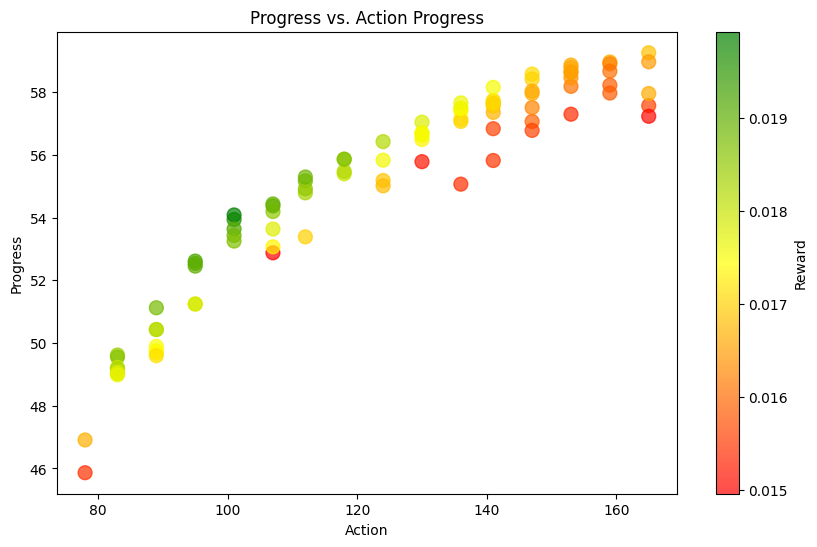

In [21]:
data = pd.read_csv(csv_file_path)

# Create DataFrame
df = pd.DataFrame(data)
cmap = mcolors.LinearSegmentedColormap.from_list("red_to_green", ["red", "yellow", "green"])

# Plotting the reward for each action
plt.figure(figsize=(10, 6))
plt.scatter(df['Action'], df['Next_Progress'], c=df['Reward'], cmap=cmap, s=100, alpha=0.7)

# Adding labels and title
plt.xlabel("Action")
plt.ylabel("Progress")
plt.title("Progress vs. Action Progress")
plt.colorbar(label='Reward')

# Show the plot
plt.show()